# Supervised Learning - Stage 3: Multiclass Classification

**Target:** `collision_severity` (Fatal / Serious / Slight)

Three classifiers are trained and compared on the same data:

| Model | Rationale |
|-------|-----------|
| Logistic Regression | Interpretable linear baseline; coefficients reveal per-feature influence per class |
| Random Forest | Non-linear ensemble; captures feature interactions; no scaling required |
| XGBoost | Sequential boosting; focuses on hard-to-classify samples; strongest on tabular data |

---
# 1. Configuration and Imports

In [18]:
import os
import pickle
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')


def find_project_root(marker='config.yml'):
    current = Path().resolve()
    for parent in [current, *current.parents]:
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(f'Could not find {marker} in any parent directory')


ROOT_DIR = find_project_root()
NOTEBOOKS_DIR = ROOT_DIR / 'notebooks'

with open(ROOT_DIR / 'config.yml') as f:
    cfg = yaml.safe_load(f)

with open(NOTEBOOKS_DIR / 'notebook-config.yml') as f:
    nb_cfg = yaml.safe_load(f)

NB_CONFIG = {
    'figsize_wide':    nb_cfg['plotting']['figsize_wide'],
    'figsize_square':  nb_cfg['plotting']['figsize_square'],
    'palette':         nb_cfg['plotting']['palette'],
    'severity_labels': {int(k): v for k, v in nb_cfg['labels']['severity'].items()},
}

sns.set_theme(style='whitegrid', palette=NB_CONFIG['palette'])
print(f'Project root: {ROOT_DIR}')
print('Configs loaded.')

Project root: /home/zayeer/Projects/Sheffield-Road-Collision-Detection-Coursework
Configs loaded.


---
# 2. Load Stage 2 Outputs

In [19]:
with open(NOTEBOOKS_DIR / 'stage_outputs' / 'stage2-multiclass.pkl', 'rb') as f:
    stage2 = pickle.load(f)

X_train = stage2['X_train']
y_train = stage2['y_train']
X_test  = stage2['X_test']
y_test  = stage2['y_test']
smote_applied = stage2['smote_applied']

# class_weight='balanced' is only needed when SMOTE was not applied
class_weight = None if smote_applied else 'balanced'

class_names = [NB_CONFIG['severity_labels'][c] for c in sorted(y_test.unique())]

print(f'Training set:  {X_train.shape}')
print(f'Test set:      {X_test.shape}')
print(f'Classes:       {class_names}')
print(f'SMOTE applied: {smote_applied}')
print(f'class_weight:  {class_weight}')

Training set:  (14508, 26)
Test set:      (1452, 26)
Classes:       ['Fatal', 'Serious', 'Slight']
SMOTE applied: True
class_weight:  None


---
# 3. Feature Scaling

StandardScaler is applied for consistency across all three models. It is required
for Logistic Regression (gradient-based optimization is sensitive to feature magnitude)
and harmless for RF and XGB (tree splits are invariant to monotonic transformations).

The scaler is fit on the training set only to prevent data leakage into the test set.

In [20]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'X_train_scaled: {X_train_scaled.shape}')
print(f'X_test_scaled:  {X_test_scaled.shape}')

X_train_scaled: (14508, 26)
X_test_scaled:  (1452, 26)


---
# 4. Shared Utilities

In [21]:
def evaluate(model_name, y_test, y_pred, class_names):
    """Compute and print standard classification metrics. Returns a result dict."""
    accuracy     = accuracy_score(y_test, y_pred)
    f1_weighted  = f1_score(y_test, y_pred, average='weighted')
    f1_macro     = f1_score(y_test, y_pred, average='macro')
    f1_per_class = f1_score(y_test, y_pred, average=None)

    print(f'--- {model_name} ---')
    print(f'Accuracy:    {accuracy:.4f}')
    print(f'Weighted F1: {f1_weighted:.4f}')
    print(f'Macro F1:    {f1_macro:.4f}')
    print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

    return {
        'model_name':   model_name,
        'accuracy':     accuracy,
        'f1_weighted':  f1_weighted,
        'f1_macro':     f1_macro,
        'f1_per_class': f1_per_class,
        'y_pred':       y_pred,
    }


def plot_confusion_matrix(ax, y_test, y_pred, class_names, title):
    """Plot a confusion matrix on the given axes."""
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontsize=10, fontweight='bold')


cv = StratifiedKFold(
    n_splits=cfg['supervised']['cv_folds'],
    shuffle=True,
    random_state=cfg['supervised']['random_state'],
)

results = {}

---
# 5. Logistic Regression

In [22]:
lr_cfg = cfg['supervised']['models']['logistic_regression']

lr_model = LogisticRegression(
    max_iter=lr_cfg['max_iter'],
    class_weight=class_weight,
    solver='lbfgs',
    random_state=cfg['supervised']['random_state'],
)
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)
results['Logistic Regression'] = evaluate('Logistic Regression', y_test, y_pred_lr, class_names)
results['Logistic Regression']['model']  = lr_model
results['Logistic Regression']['scaler'] = scaler

--- Logistic Regression ---
Accuracy:    0.5028
Weighted F1: 0.5858
Macro F1:    0.3036
              precision    recall  f1-score   support

       Fatal     0.0217    0.3333    0.0407        18
     Serious     0.1608    0.2857    0.2058       224
      Slight     0.8494    0.5455    0.6643      1210

    accuracy                         0.5028      1452
   macro avg     0.3440    0.3882    0.3036      1452
weighted avg     0.7329    0.5028    0.5858      1452



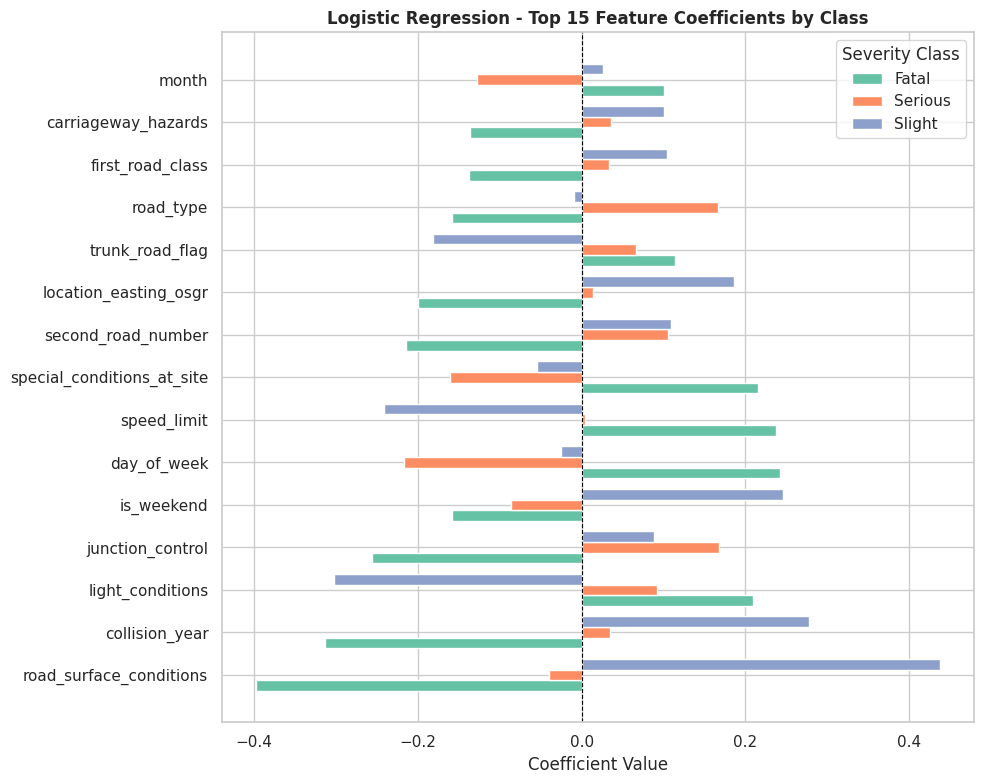

In [23]:
feature_names = X_train.columns.tolist()
coef_df = pd.DataFrame(
    lr_model.coef_,
    index=class_names,
    columns=feature_names
).T
coef_df['mean_abs'] = coef_df.abs().mean(axis=1)
top_features = coef_df.nlargest(15, 'mean_abs').drop(columns='mean_abs')

fig, ax = plt.subplots(figsize=tuple(NB_CONFIG['figsize_square']))
palette = sns.color_palette(NB_CONFIG['palette'], len(class_names))
x = np.arange(len(top_features))
width = 0.25

for i, (cls_name, color) in enumerate(zip(class_names, palette, strict=False)):
    ax.barh(x + i * width, top_features[cls_name], height=width, label=cls_name, color=color)

ax.set_yticks(x + width)
ax.set_yticklabels(top_features.index)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Coefficient Value')
ax.set_title('Logistic Regression - Top 15 Feature Coefficients by Class',
             fontsize=12, fontweight='bold')
ax.legend(title='Severity Class')
plt.tight_layout()
plt.show()

---
# 6. Random Forest

In [24]:
rf_cfg = cfg['supervised']['models']['random_forest']

param_grid_rf = {
    'n_estimators':      rf_cfg['n_estimators'],
    'max_depth':         rf_cfg['max_depth'],
    'min_samples_split': rf_cfg['min_samples_split'],
}

base_rf = RandomForestClassifier(
    class_weight=class_weight, # type: ignore
    random_state=cfg['supervised']['random_state'],
    n_jobs=-1,
)

search_rf = GridSearchCV(
    estimator=base_rf,
    param_grid=param_grid_rf,
    scoring='f1_macro',
    cv=cv,
    n_jobs=-1,
    verbose=1,
)

print('Running GridSearchCV for Random Forest...')
search_rf.fit(X_train, y_train)

print(f'Best params:        {search_rf.best_params_}')
print(f'Best macro F1 (CV): {search_rf.best_score_:.4f}')

Running GridSearchCV for Random Forest...
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best params:        {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 300}
Best macro F1 (CV): 0.9173


In [25]:
rf_model  = search_rf.best_estimator_
y_pred_rf = rf_model.predict(X_test)
results['Random Forest'] = evaluate('Random Forest', y_test, y_pred_rf, class_names)
results['Random Forest']['model']       = rf_model
results['Random Forest']['best_params'] = search_rf.best_params_

--- Random Forest ---
Accuracy:    0.7700
Weighted F1: 0.7523
Macro F1:    0.3502
              precision    recall  f1-score   support

       Fatal     0.0000    0.0000    0.0000        18
     Serious     0.2160    0.1562    0.1813       224
      Slight     0.8448    0.8950    0.8692      1210

    accuracy                         0.7700      1452
   macro avg     0.3536    0.3504    0.3502      1452
weighted avg     0.7373    0.7700    0.7523      1452



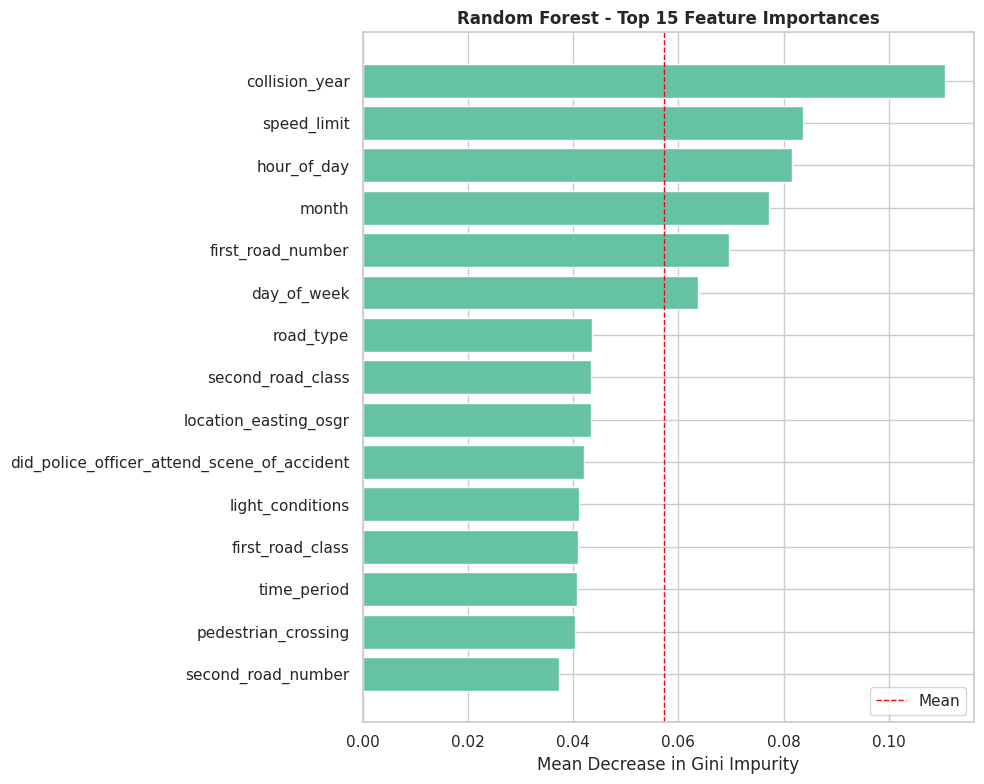

In [26]:
importances = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=tuple(NB_CONFIG['figsize_square']))
ax.barh(importances.index, importances.values, # type: ignore
        color=sns.color_palette(NB_CONFIG['palette'])[0])
ax.axvline(importances.mean(), color='red', linestyle='--', linewidth=1, label='Mean')
ax.set_xlabel('Mean Decrease in Gini Impurity')
ax.set_title('Random Forest - Top 15 Feature Importances', fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

---
# 7. XGBoost

XGBoost requires zero-indexed labels. The raw target encodes severity as
1/2/3 so we remap to 0/1/2 for training and invert after prediction to keep
all comparisons consistent with Logistic Regression and Random Forest.

In [27]:
original_classes = sorted(y_train.unique())  # [1, 2, 3]
label_map        = {orig: idx for idx, orig in enumerate(original_classes)}
inverse_map      = {idx: orig for orig, idx in label_map.items()}

y_train_enc = y_train.map(label_map)
y_test_enc  = y_test.map(label_map)

print('Label mapping (original -> XGBoost internal):')
for orig, enc in label_map.items():
    print(f'  {NB_CONFIG["severity_labels"][orig]:8s} (class {orig}) -> {enc}')

Label mapping (original -> XGBoost internal):
  Fatal    (class 1) -> 0
  Serious  (class 2) -> 1
  Slight   (class 3) -> 2


In [28]:
xgb_cfg = cfg['supervised']['models']['xgboost']

param_grid_xgb = {
    'learning_rate': xgb_cfg['learning_rate'],
    'max_depth':     xgb_cfg['max_depth'],
    'n_estimators':  xgb_cfg['n_estimators'],
    'subsample':     xgb_cfg['subsample'],
}

base_xgb = XGBClassifier(
    objective='multi:softprob',
    num_class=len(original_classes),
    eval_metric='mlogloss',
    random_state=cfg['supervised']['random_state'],
    n_jobs=-1,
    verbosity=0,
)

search_xgb = GridSearchCV(
    estimator=base_xgb,
    param_grid=param_grid_xgb,
    scoring='f1_macro',
    cv=cv,
    n_jobs=-1,
    verbose=1,
)

print('Running GridSearchCV for XGBoost...')
search_xgb.fit(X_train, y_train_enc)

print(f'Best params:        {search_xgb.best_params_}')
print(f'Best macro F1 (CV): {search_xgb.best_score_:.4f}')

Running GridSearchCV for XGBoost...
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best params:        {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}
Best macro F1 (CV): 0.9136


In [29]:
xgb_model  = search_xgb.best_estimator_
y_pred_enc = xgb_model.predict(X_test)
y_pred_xgb = pd.Series(y_pred_enc).map(inverse_map).values

results['XGBoost'] = evaluate('XGBoost', y_test, y_pred_xgb, class_names)
results['XGBoost']['model']       = xgb_model
results['XGBoost']['best_params'] = search_xgb.best_params_
results['XGBoost']['label_map']   = label_map
results['XGBoost']['inverse_map'] = inverse_map

--- XGBoost ---
Accuracy:    0.7624
Weighted F1: 0.7465
Macro F1:    0.3454
              precision    recall  f1-score   support

       Fatal     0.0000    0.0000    0.0000        18
     Serious     0.1988    0.1518    0.1722       224
      Slight     0.8422    0.8868    0.8639      1210

    accuracy                         0.7624      1452
   macro avg     0.3470    0.3462    0.3454      1452
weighted avg     0.7325    0.7624    0.7465      1452



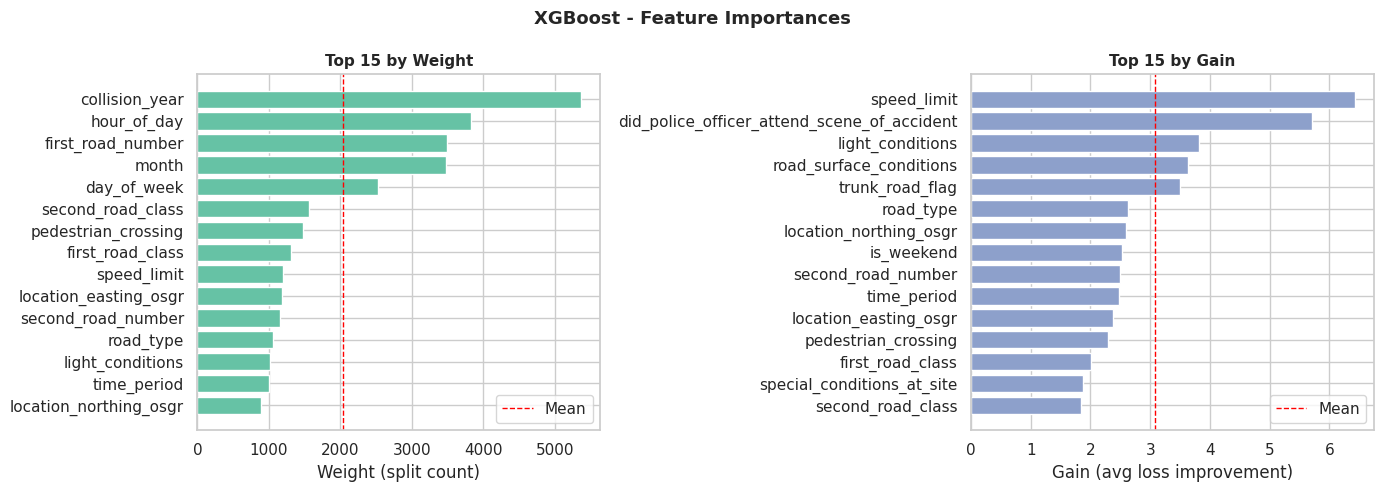

In [30]:
importance_weight = pd.Series(
    xgb_model.get_booster().get_score(importance_type='weight'),
    name='weight'
).reindex(X_train.columns, fill_value=0).sort_values(ascending=True).tail(15)

importance_gain = pd.Series(
    xgb_model.get_booster().get_score(importance_type='gain'),
    name='gain'
).reindex(X_train.columns, fill_value=0).sort_values(ascending=True).tail(15)

fig, axes = plt.subplots(1, 2, figsize=tuple(NB_CONFIG['figsize_wide']))
palette = sns.color_palette(NB_CONFIG['palette'])

axes[0].barh(importance_weight.index, importance_weight.values, color=palette[0])
axes[0].axvline(importance_weight.mean(), color='red', linestyle='--', linewidth=1, label='Mean')
axes[0].set_xlabel('Weight (split count)')
axes[0].set_title('Top 15 by Weight', fontsize=11, fontweight='bold')
axes[0].legend()

axes[1].barh(importance_gain.index, importance_gain.values, color=palette[2])
axes[1].axvline(importance_gain.mean(), color='red', linestyle='--', linewidth=1, label='Mean')
axes[1].set_xlabel('Gain (avg loss improvement)')
axes[1].set_title('Top 15 by Gain', fontsize=11, fontweight='bold')
axes[1].legend()

fig.suptitle('XGBoost - Feature Importances', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
# 8. Model Comparison

In [31]:
comparison_rows = []
for model_name, r in results.items():
    row = {
        'Model':       model_name,
        'Accuracy':    r['accuracy'],
        'Weighted F1': r['f1_weighted'],
        'Macro F1':    r['f1_macro'],
    }
    for cls_name, f1 in zip(class_names, r['f1_per_class'], strict=False):
        row[f'F1 ({cls_name})'] = f1
    comparison_rows.append(row)

comparison_df = pd.DataFrame(comparison_rows).set_index('Model').round(4)
print('Model comparison:')
comparison_df

Model comparison:


,Accuracy,Weighted F1,Macro F1,F1 (Fatal),F1 (Serious),F1 (Slight)
Model,,,,,,
Logistic Regression,0.5028,0.5858,0.3036,0.0407,0.2058,0.6643
Random Forest,0.7700,0.7523,0.3502,0.0000,0.1813,0.8692
XGBoost,0.7624,0.7465,0.3454,0.0000,0.1722,0.8639


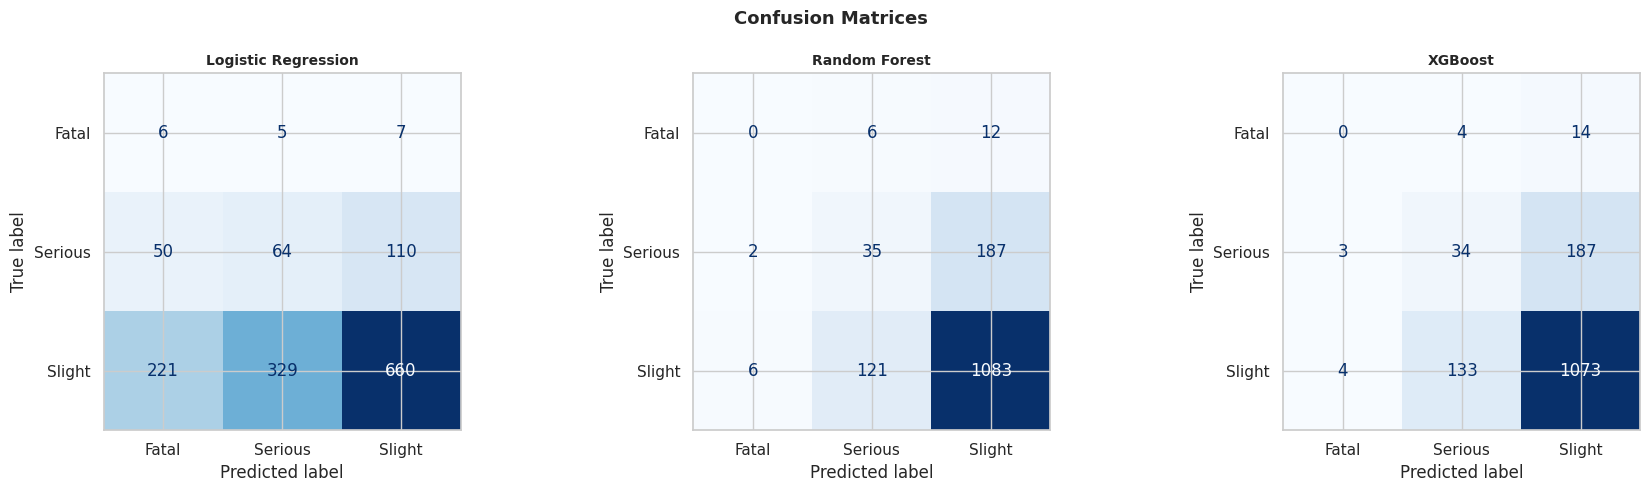

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (model_name, r) in zip(axes, results.items(), strict=False):
    plot_confusion_matrix(ax, y_test, r['y_pred'], class_names, model_name)

fig.suptitle('Confusion Matrices', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

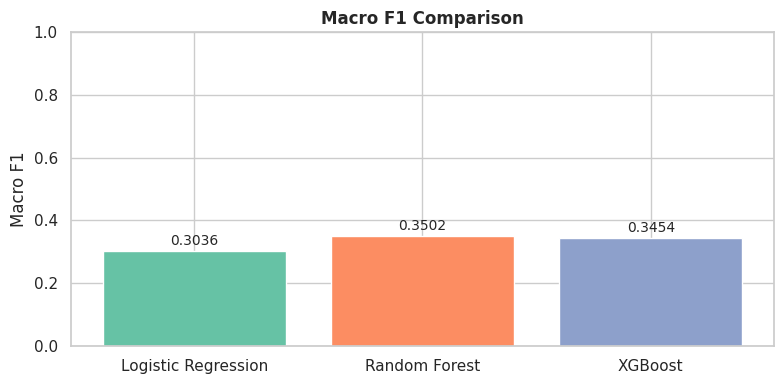

In [33]:
fig, ax = plt.subplots(figsize=(8, 4))
palette = sns.color_palette(NB_CONFIG['palette'], len(results))
bars = ax.bar(list(results.keys()),
              [r['f1_macro'] for r in results.values()],
              color=palette, edgecolor='white')
for bar, r in zip(bars, results.values(), strict=False):
    ax.annotate(
        f'{r["f1_macro"]:.4f}',
        xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
        xytext=(0, 4), textcoords='offset points',
        ha='center', fontsize=10
    )
ax.set_ylabel('Macro F1')
ax.set_title('Macro F1 Comparison', fontsize=12, fontweight='bold')
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

---
# 9. Persist Stage 3 Outputs

In [34]:
output_dir = NOTEBOOKS_DIR / 'stage_outputs'
os.makedirs(output_dir, exist_ok=True)

output_path = output_dir / 'stage3.pkl'
with open(output_path, 'wb') as f:
    pickle.dump({
        'task':          'multiclass',
        'target_col':    'collision_severity',
        'class_names':   class_names,
        'results':       {
            model_name: {
                'accuracy':     r['accuracy'],
                'f1_weighted':  r['f1_weighted'],
                'f1_macro':     r['f1_macro'],
                'f1_per_class': r['f1_per_class'],
                'y_pred':       r['y_pred'],
                'model':        r['model'],
                'best_params':  r.get('best_params', None),
            }
            for model_name, r in results.items()
        },
        'scaler':        scaler,
        'y_test':        y_test,
        'X_test':        X_test,
        'comparison_df': comparison_df,
    }, f)

print(f'Stage 3 outputs saved to: {output_path}')

Stage 3 outputs saved to: /home/zayeer/Projects/Sheffield-Road-Collision-Detection-Coursework/notebooks/stage_outputs/stage3.pkl
